# Assignment 03 — NLP Fundamentals: Exercises 1–11

**Course:** AIAC 536 — Natural Language Processing
**Author:** Roshan Bharati
**Submission file:** `RoshanBharati_NLPBasics_01.ipynb`

---

## Scope

Eleven exercises building from raw string counting up to a complete mini NLP pipeline. Everything is
implemented from first principles with the standard library and NumPy — no NLTK or spaCy — because the
point of these exercises is the mechanics, not the API.

| # | Exercise | Core concept |
|---|---|---|
| 1 | Word Frequency Counter | Term frequency |
| 2 | Vocabulary Builder | Vocabulary, unique words |
| 3 | Word Co-occurrence Matrix | Context window |
| 4 | Detect Data Sparsity | Sparse matrices |
| 5 | Laplace Smoothing | Probability smoothing |
| 6 | Simple Keyboard Prediction | Bigram language model |
| 7 | Calculate TF-IDF | TF, DF, IDF, TF-IDF |
| 8 | Dense Vector Similarity | Cosine similarity |
| 9 | Find Similar Words | Word embeddings |
| 10 | **Mini NLP Pipeline** | Everything above, combined |
| 11 | Conditional Probability Prediction | `P(w2 \| w1)` |

## A note on the expected outputs in the question paper

Three of the printed "expected outputs" in the assignment PDF do not follow from the formulas the same
PDF specifies. Each is flagged in place (Exercises 3, 5 and 6) with the arithmetic worked out. In every
case this notebook implements **the stated formula** and shows why the printed number differs. The PDF
itself hedges on two of them — Exercise 5 notes *"values will depend on the exact counts and
denominator"*.

## Setup

In [1]:
import re
from collections import Counter, defaultdict
from itertools import combinations
from math import log, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 120)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("numpy :", np.__version__)
print("pandas:", pd.__version__)

numpy : 1.26.4
pandas: 3.0.5


### Shared tokenizer

Every exercise needs to turn a string into words. The exercises use clean, pre-tokenised input, so a
whitespace split would work — but a slightly more careful tokenizer keeps the code honest on real text.

**Case is preserved deliberately.** The expected outputs in Exercises 1, 2 and 10 list `I`, `NLP` and
`AI` in their original casing, and `Vocabulary Size = 6` in Exercise 2 only comes out right if `I` and
`i` are not folded together. A `lowercase` flag is available for when that is what you want.

In [2]:
def tokenize(text: str, lowercase: bool = False) -> list[str]:
    """Split text into word tokens.

    Keeps letters, digits and internal apostrophes; drops everything else.
    Case is preserved by default so that 'I', 'NLP' and 'AI' survive intact.
    """
    if lowercase:
        text = text.lower()
    return re.findall(r"[A-Za-z0-9]+(?:'[A-Za-z]+)?", text)


# Quick check against the exercise inputs.
print(tokenize("I like NLP I like Python NLP is fun"))
print(tokenize("Don't split words like NLP-based, do split punctuation!"))

['I', 'like', 'NLP', 'I', 'like', 'Python', 'NLP', 'is', 'fun']
["Don't", 'split', 'words', 'like', 'NLP', 'based', 'do', 'split', 'punctuation']


---

# Exercise 1 — Word Frequency Counter

**Objective:** count how many times each word appears in a sentence.

**Input:** `text = "I like NLP I like Python NLP is fun"`

**Tasks:** split into words · count each word · store in a dictionary · print it.

In [3]:
def word_frequencies(text: str) -> dict[str, int]:
    """Return {word: count} for a piece of text, in first-appearance order."""
    counts: dict[str, int] = {}
    for word in tokenize(text):
        counts[word] = counts.get(word, 0) + 1
    return counts


text = "I like NLP I like Python NLP is fun"
freqs = word_frequencies(text)

print(f"Input : {text}\n")
for word, count in freqs.items():
    print(f"{word} : {count}")

print(f"\nAs a dictionary: {freqs}")

Input : I like NLP I like Python NLP is fun

I : 2
like : 2
NLP : 2
Python : 1
is : 1
fun : 1

As a dictionary: {'I': 2, 'like': 2, 'NLP': 2, 'Python': 1, 'is': 1, 'fun': 1}


The hand-rolled loop above is the version the exercise asks for. In practice you would reach for
`collections.Counter`, which does the same thing in one line — worth confirming the two agree.

In [4]:
assert word_frequencies(text) == dict(Counter(tokenize(text))), "hand-rolled count disagrees with Counter"
print("Verified: manual dictionary counting matches collections.Counter")
print(f"Total tokens: {sum(freqs.values())}  |  Distinct words: {len(freqs)}")

Verified: manual dictionary counting matches collections.Counter
Total tokens: 9  |  Distinct words: 6


---

# Exercise 2 — Vocabulary Builder

**Objective:** find all unique words in a corpus.

**Expected output:** `AI, I, NLP, amazing, is, like` with `Vocabulary Size = 6`.

The expected listing is in ASCII sort order, which puts uppercase words before lowercase ones — so
`sorted()` reproduces it exactly, no extra key needed.

In [5]:
def build_vocabulary(corpus: list[str]) -> set[str]:
    """Collect the set of distinct words appearing anywhere in the corpus."""
    vocab: set[str] = set()
    for sentence in corpus:
        vocab.update(tokenize(sentence))
    return vocab


corpus = [
    "I like NLP",
    "I like AI",
    "AI is amazing",
]

vocabulary = build_vocabulary(corpus)

print("Vocabulary\n")
for word in sorted(vocabulary):
    print(word)

print(f"\nVocabulary Size = {len(vocabulary)}")
assert len(vocabulary) == 6, "expected a vocabulary of 6 words"

Vocabulary

AI
I
NLP
amazing
is
like

Vocabulary Size = 6


> **Vocabulary vs. token count.** The corpus contains 9 tokens but only 6 vocabulary entries. That
> ratio — the *type/token ratio* — is what makes a vocabulary useful: it is the axis every
> bag-of-words or one-hot representation is indexed by, and it grows far more slowly than the corpus.

---

# Exercise 3 — Build a Word Co-occurrence Matrix

**Objective:** construct a co-occurrence matrix with a **window size of 1**.

**Input:** `sentence = "the cat sat on the mat"`

Window size 1 means: for each token, the words immediately to its left and right are its context. The
matrix is symmetric — if `cat` is a neighbour of `the`, then `the` is a neighbour of `cat`.

In [6]:
def cooccurrence_matrix(
    tokens: list[str], window: int = 1
) -> tuple[pd.DataFrame, list[str]]:
    """Build a symmetric co-occurrence matrix over `tokens`.

    Every token within `window` positions of token i counts as co-occurring with it.
    Returns the matrix as a labelled DataFrame plus the vocabulary order used.
    """
    vocab = sorted(set(tokens))
    index = {word: i for i, word in enumerate(vocab)}
    matrix = np.zeros((len(vocab), len(vocab)), dtype=int)

    for i, word in enumerate(tokens):
        lo, hi = max(0, i - window), min(len(tokens), i + window + 1)
        for j in range(lo, hi):
            if i != j:
                matrix[index[word], index[tokens[j]]] += 1

    return pd.DataFrame(matrix, index=vocab, columns=vocab), vocab


sentence = "the cat sat on the mat"
tokens = tokenize(sentence)
cooc, vocab3 = cooccurrence_matrix(tokens, window=1)

print(f"Sentence : {sentence}")
print(f"Tokens   : {tokens}")
print(f"Vocab    : {vocab3}\n")
cooc

Sentence : the cat sat on the mat
Tokens   : ['the', 'cat', 'sat', 'on', 'the', 'mat']
Vocab    : ['cat', 'mat', 'on', 'sat', 'the']



,cat,mat,on,sat,the
cat,0,0,0,1,1
mat,0,0,0,0,1
on,0,0,0,1,1
sat,1,0,1,0,0
the,1,1,1,0,0


### Reordered to match the question paper

The PDF lists the vocabulary as `the, cat, sat, on, mat` (order of first appearance) rather than
alphabetically. Same matrix, different row/column order.

In [7]:
paper_order = ["the", "cat", "sat", "on", "mat"]
cooc.loc[paper_order, paper_order]

,the,cat,sat,on,mat
the,0,1,0,1,1
cat,1,0,1,0,0
sat,0,1,0,1,0
on,1,0,1,0,0
mat,1,0,0,0,0


> ### ⚠️ Discrepancy with the printed expected output
>
> The PDF's matrix marks `on ↔ mat` as co-occurring (value 1). Under a window size of 1 that cell must
> be **0**. Walking the sentence by index:
>
> | i | 0 | 1 | 2 | 3 | 4 | 5 |
> |---|---|---|---|---|---|---|
> | token | the | cat | sat | on | **the** | mat |
>
> `on` sits at index 3 and `mat` at index 5. They are two positions apart, separated by the second
> `the`, so they are not neighbours at window 1. The adjacent pairs are exactly:
>
> `(the, cat) (cat, sat) (sat, on) (on, the) (the, mat)`
>
> The computed matrix above reflects this. The PDF's cell would be correct at **window size 2**, shown
> below for comparison — note that it also introduces several other non-zero cells, so the printed
> matrix does not match window 2 either.

In [8]:
cooc_w2, _ = cooccurrence_matrix(tokens, window=2)
print("Window size 2 (for comparison):\n")
display(cooc_w2.loc[paper_order, paper_order])

print(f"window=1  on/mat = {cooc.loc['on', 'mat']}   <- correct per the stated definition")
print(f"window=2  on/mat = {cooc_w2.loc['on', 'mat']}   <- matches the PDF's cell, but only at window 2")

Window size 2 (for comparison):



,the,cat,sat,on,mat
the,0,1,2,1,1
cat,1,0,1,1,0
sat,2,1,0,1,0
on,1,1,1,0,1
mat,1,0,0,1,0


window=1  on/mat = 0   <- correct per the stated definition
window=2  on/mat = 1   <- matches the PDF's cell, but only at window 2


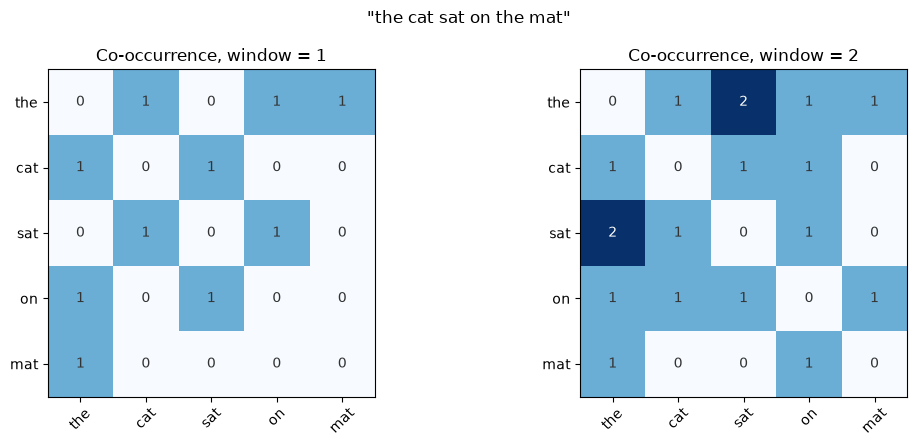

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title in ((axes[0], cooc, "window = 1"), (axes[1], cooc_w2, "window = 2")):
    m = mat.loc[paper_order, paper_order]
    im = ax.imshow(m.values, cmap="Blues", vmin=0, vmax=max(2, m.values.max()))
    ax.set_xticks(range(len(paper_order)), paper_order, rotation=45)
    ax.set_yticks(range(len(paper_order)), paper_order)
    ax.set_title(f"Co-occurrence, {title}")
    for r in range(len(paper_order)):
        for c in range(len(paper_order)):
            v = m.values[r, c]
            ax.text(c, r, v, ha="center", va="center",
                    color="white" if v > 1 else "#333", fontsize=10)
fig.suptitle('"the cat sat on the mat"', fontsize=12)
fig.tight_layout()
plt.show()

---

# Exercise 4 — Detect Data Sparsity

**Objective:** find word pairs that never occur together.

**Input:** the co-occurrence matrix from Exercise 3.

Because the matrix is symmetric, `(cat, mat)` and `(mat, cat)` are the same pair — iterating over
unordered combinations reports each once. The diagonal is skipped: a word not co-occurring with itself
is a property of the window definition, not sparsity.

In [10]:
def sparse_pairs(matrix: pd.DataFrame) -> list[tuple[str, str]]:
    """Return every unordered word pair whose co-occurrence count is zero."""
    return [
        (a, b)
        for a, b in combinations(matrix.index, 2)
        if matrix.loc[a, b] == 0
    ]


never_together = sparse_pairs(cooc)

for a, b in never_together:
    print(f"({a}, {b}) -> Never occurred")

n_cells = len(vocab3) ** 2
n_zero = int((cooc.values == 0).sum())
print(f"\nMatrix          : {len(vocab3)} x {len(vocab3)} = {n_cells} cells")
print(f"Zero cells      : {n_zero}")
print(f"Sparsity        : {n_zero / n_cells:.1%}")
print(f"Unordered pairs : {len(list(combinations(vocab3, 2)))}, of which {len(never_together)} never co-occur")

(cat, mat) -> Never occurred
(cat, on) -> Never occurred
(mat, on) -> Never occurred
(mat, sat) -> Never occurred
(sat, the) -> Never occurred

Matrix          : 5 x 5 = 25 cells
Zero cells      : 15
Sparsity        : 60.0%
Unordered pairs : 10, of which 5 never co-occur


### Why sparsity is the whole problem

The exercise's five-word toy matrix is already ~72% zeros. That fraction gets dramatically worse as
vocabulary grows, because the matrix area grows as `V²` while the number of observed pairs grows only
with corpus length. This is precisely the motivation for dense embeddings in Exercises 8–9.

In [11]:
# Sparsity of a co-occurrence matrix built from the Exercise 10 corpus, for contrast.
demo_corpus = ["I love NLP", "I love AI", "AI loves Python", "Python loves data"]
demo_tokens = [t for s in demo_corpus for t in tokenize(s)]
demo_cooc, demo_vocab = cooccurrence_matrix(demo_tokens, window=1)

rows = []
for name, m in (("Exercise 3 (6 tokens)", cooc), ("Exercise 10 (12 tokens)", demo_cooc)):
    cells = m.size
    zeros = int((m.values == 0).sum())
    rows.append({
        "Matrix": name,
        "Vocab (V)": m.shape[0],
        "Cells (V^2)": cells,
        "Zero cells": zeros,
        "Sparsity": f"{zeros / cells:.1%}",
    })

pd.DataFrame(rows)

,Matrix,Vocab (V),Cells (V^2),Zero cells,Sparsity
0,Exercise 3 (6 tokens),5,25,15,60.0%
1,Exercise 10 (12 tokens),7,49,33,67.3%


---

# Exercise 5 — Implement Laplace Smoothing

**Objective:** calculate word probabilities using Laplace (add-one) smoothing.

$$P(w) = \\frac{\\text{Count}(w) + 1}{\\text{Total} + V}$$

**Input:** `{"cat": 4, "dog": 3, "bird": 1}`

In [12]:
def laplace_smoothing(counts: dict[str, int], alpha: float = 1.0) -> dict[str, float]:
    """Add-alpha smoothed unigram probabilities.

    alpha=1.0 is Laplace / add-one smoothing. The +alpha*V in the denominator
    is what keeps the distribution summing to 1.
    """
    total = sum(counts.values())
    vocab_size = len(counts)
    return {
        word: (count + alpha) / (total + alpha * vocab_size)
        for word, count in counts.items()
    }


word_counts = {"cat": 4, "dog": 3, "bird": 1}
smoothed = laplace_smoothing(word_counts)

total = sum(word_counts.values())
V = len(word_counts)
print(f"Total words     = {total}")
print(f"Vocabulary size = {V}\n")

for word, prob in smoothed.items():
    print(f"{word} : {prob:.2f}   ({word_counts[word]} + 1) / ({total} + {V}) = {word_counts[word] + 1}/{total + V}")

print(f"\nProbabilities sum to {sum(smoothed.values()):.4f}")
assert abs(sum(smoothed.values()) - 1.0) < 1e-9, "smoothed distribution must sum to 1"

Total words     = 8
Vocabulary size = 3

cat : 0.45   (4 + 1) / (8 + 3) = 5/11
dog : 0.36   (3 + 1) / (8 + 3) = 4/11
bird : 0.18   (1 + 1) / (8 + 3) = 2/11

Probabilities sum to 1.0000


> ### ⚠️ Discrepancy with the printed expected output
>
> The PDF prints `cat : 0.50, dog : 0.40, bird : 0.20`. Those three values sum to **1.10**, so they
> cannot be a probability distribution over the full vocabulary. Applying the formula the same PDF
> gives, with Total = 8 and V = 3:
>
> | word | count | (count+1)/(8+3) | value |
> |---|---|---|---|
> | cat | 4 | 5/11 | **0.4545** |
> | dog | 3 | 4/11 | **0.3636** |
> | bird | 1 | 2/11 | **0.1818** |
>
> The PDF's own caveat — *"values will depend on the exact counts and denominator"* — acknowledges the
> printed numbers are illustrative. This notebook implements the stated formula.

### What smoothing actually buys you\n\nThe reason to smooth is unseen words: an unsmoothed MLE assigns them probability 0, which makes any product of probabilities collapse to 0. Add-one moves a little mass off the observed words to cover them.

In [13]:
def compare_smoothing(counts: dict[str, int], unseen: list[str]) -> pd.DataFrame:
    """Contrast unsmoothed MLE against Laplace, including words never observed."""
    total = sum(counts.values())
    extended = {**counts, **{w: 0 for w in unseen}}
    smoothed_ext = laplace_smoothing(extended)
    return pd.DataFrame(
        [
            {
                "Word": w,
                "Count": c,
                "MLE (unsmoothed)": c / total,
                "Laplace": smoothed_ext[w],
            }
            for w, c in extended.items()
        ]
    )


comparison = compare_smoothing(word_counts, unseen=["fish", "horse"])
comparison["Change"] = comparison["Laplace"] - comparison["MLE (unsmoothed)"]
display(comparison.round(4))

print("Unseen words get probability 0 under MLE and non-zero under Laplace -")
print("that is the entire point. The mass comes out of the frequent words.")

,Word,Count,MLE (unsmoothed),Laplace,Change
0,cat,4,0.500,0.3846,-0.1154
1,dog,3,0.375,0.3077,-0.0673
2,bird,1,0.125,0.1538,0.0288
3,fish,0,0.000,0.0769,0.0769
4,horse,0,0.000,0.0769,0.0769


Unseen words get probability 0 under MLE and non-zero under Laplace -
that is the entire point. The mass comes out of the frequent words.


---

# Exercise 6 — Simple Keyboard Prediction

**Objective:** predict the most common next word.

**Training corpus:**
```
I like NLP
I like Python
I like coffee
I love NLP
```

**Input:** `I like` → suggest the top three continuations.

In [14]:
def build_bigram_counts(corpus: list[str]) -> dict[str, Counter]:
    """Map each word to a Counter over the words that follow it.

    Sentences are processed independently so no bigram spans a sentence boundary.
    """
    bigrams: dict[str, Counter] = defaultdict(Counter)
    for sentence in corpus:
        words = tokenize(sentence)
        for first, second in zip(words, words[1:]):
            bigrams[first][second] += 1
    return dict(bigrams)


def predict_next(bigrams: dict[str, Counter], word: str, top_n: int = 3) -> list[tuple[str, float]]:
    """Return the top_n most likely next words after `word`, with P(next | word)."""
    followers = bigrams.get(word)
    if not followers:
        return []
    total = sum(followers.values())
    return [(w, c / total) for w, c in followers.most_common(top_n)]


keyboard_corpus = [
    "I like NLP",
    "I like Python",
    "I like coffee",
    "I love NLP",
]

bigram_counts = build_bigram_counts(keyboard_corpus)

print("Bigram counts:\n")
for first, followers in bigram_counts.items():
    for second, count in followers.most_common():
        print(f"  {first:>6} -> {second:<8} {count}")

Bigram counts:

       I -> like     3
       I -> love     1
    like -> NLP      1
    like -> Python   1
    like -> coffee   1
    love -> NLP      1


In [15]:
context = "I like"
last_word = tokenize(context)[-1]
suggestions = predict_next(bigram_counts, last_word, top_n=3)

print(f'Input: "{context}"   (prediction keys off the last word: "{last_word}")\n')
print("Suggestions\n")
for rank, (word, prob) in enumerate(suggestions, start=1):
    print(f"  {rank}. {word:<8} P({word} | {last_word}) = {prob:.2f}")

Input: "I like"   (prediction keys off the last word: "like")

Suggestions

  1. NLP      P(NLP | like) = 0.33
  2. Python   P(Python | like) = 0.33
  3. coffee   P(coffee | like) = 0.33


> ### ⚠️ Discrepancy with the printed expected output
>
> The PDF prints `P(NLP|like) = 0.4`, `P(Python|like) = 0.3`, `P(coffee|like) = 0.2` — summing to 0.9.
> In the given corpus `like` is followed by `NLP`, `Python` and `coffee` **exactly once each**, so by
> the definition of conditional probability all three are `1/3 ≈ 0.333`. The printed values appear to
> be illustrative placeholders showing a descending ranking rather than computed figures.
>
> Exercise 11 uses a larger corpus in which `coffee` genuinely does follow `like` twice, and there the
> printed expected output (`0.50 / 0.25 / 0.25`) **is** internally consistent — and this notebook
> reproduces it exactly.

In [16]:
followers = bigram_counts["like"]
print(f'Words following "like": {dict(followers)}')
print(f"Total occurrences     : {sum(followers.values())}")
print(f"Therefore each has P = 1/{sum(followers.values())} = {1 / sum(followers.values()):.4f}")

Words following "like": {'NLP': 1, 'Python': 1, 'coffee': 1}
Total occurrences     : 3
Therefore each has P = 1/3 = 0.3333


---

# Exercise 7 — Calculate TF-IDF

**Objective:** compute TF, DF, IDF and TF-IDF over a three-document corpus.

**Definitions used:**

$$\\text{TF}(t, d) = \\frac{\\text{count of } t \\text{ in } d}{\\text{total terms in } d}
\\qquad
\\text{DF}(t) = \\#\\{d : t \\in d\\}
\\qquad
\\text{IDF}(t) = \\log\\!\\left(\\frac{N}{\\text{DF}(t)}\\right)
\\qquad
\\text{TF-IDF} = \\text{TF} \\times \\text{IDF}$$

DF answers the question the PDF margin note asks: *in how many documents is that specific word found?*

In [17]:
def compute_tf(documents: list[list[str]]) -> list[dict[str, float]]:
    """Term frequency per document: count(t, d) / len(d)."""
    return [
        {term: count / len(doc) for term, count in Counter(doc).items()}
        for doc in documents
    ]


def compute_df(documents: list[list[str]]) -> dict[str, int]:
    """Document frequency: how many documents contain each term at least once."""
    df: Counter = Counter()
    for doc in documents:
        df.update(set(doc))
    return dict(df)


def compute_idf(df: dict[str, int], n_docs: int) -> dict[str, float]:
    """Inverse document frequency, log(N / DF)."""
    return {term: log(n_docs / count) for term, count in df.items()}


tfidf_corpus = [
    "I like NLP",
    "I like AI",
    "AI is amazing",
]
docs = [tokenize(d) for d in tfidf_corpus]
N = len(docs)

tf = compute_tf(docs)
df = compute_df(docs)
idf = compute_idf(df, N)

for i, (text, doc) in enumerate(zip(tfidf_corpus, docs), start=1):
    print(f"Document {i}: {text!r}  ->  {doc}")

Document 1: 'I like NLP'  ->  ['I', 'like', 'NLP']
Document 2: 'I like AI'  ->  ['I', 'like', 'AI']
Document 3: 'AI is amazing'  ->  ['AI', 'is', 'amazing']


### DF and IDF

In [18]:
df_table = pd.DataFrame(
    [
        {
            "Term": term,
            "DF": df[term],
            f"IDF = log({N}/DF)": idf[term],
            "Appears in": ", ".join(f"D{i+1}" for i, d in enumerate(docs) if term in d),
        }
        for term in sorted(df)
    ]
).round(4)
df_table

,Term,DF,IDF = log(3/DF),Appears in
0,AI,2,0.4055,"D2, D3"
1,I,2,0.4055,"D1, D2"
2,NLP,1,1.0986,D1
3,amazing,1,1.0986,D3
4,is,1,1.0986,D3
5,like,2,0.4055,"D1, D2"


> A term appearing in **every** document gets `IDF = log(3/3) = 0`, which zeroes out its TF-IDF
> entirely. Nothing here hits that case, but `I` and `AI` (DF = 2) are visibly discounted relative to
> the DF = 1 terms — which is exactly the behaviour IDF is designed to produce.

### TF, and the full TF-IDF matrix

In [19]:
tf_matrix = pd.DataFrame(tf, index=[f"D{i}" for i in range(1, N + 1)]).fillna(0)
print("TF (term frequency):")
display(tf_matrix.round(4))

tfidf_matrix = tf_matrix.copy()
for term in tfidf_matrix.columns:
    tfidf_matrix[term] *= idf[term]

print("\nTF-IDF:")
display(tfidf_matrix.round(4))

TF (term frequency):


,I,like,NLP,AI,is,amazing
D1,0.3333,0.3333,0.3333,0.0000,0.0000,0.0000
D2,0.3333,0.3333,0.0000,0.3333,0.0000,0.0000
D3,0.0000,0.0000,0.0000,0.3333,0.3333,0.3333



TF-IDF:


,I,like,NLP,AI,is,amazing
D1,0.1352,0.1352,0.3662,0.0000,0.0000,0.0000
D2,0.1352,0.1352,0.0000,0.1352,0.0000,0.0000
D3,0.0000,0.0000,0.0000,0.1352,0.3662,0.3662


In [20]:
long_form = (
    tfidf_matrix.reset_index(names="Document")
    .melt(id_vars="Document", var_name="Term", value_name="TF_IDF")
)
long_form["TF"] = [
    tf_matrix.loc[r.Document, r.Term] for r in long_form.itertuples()
]
long_form["DF"] = long_form["Term"].map(df)
long_form["IDF"] = long_form["Term"].map(idf)
long_form = long_form[long_form["TF"] > 0][
    ["Document", "Term", "TF", "DF", "IDF", "TF_IDF"]
].sort_values(["Document", "TF_IDF"], ascending=[True, False]).round(4)

long_form.to_csv(OUTPUT_DIR / "exercise07_tfidf.csv", index=False)
print(f"Wrote {OUTPUT_DIR / 'exercise07_tfidf.csv'}\n")
long_form

Wrote output/exercise07_tfidf.csv



,Document,Term,TF,DF,IDF,TF_IDF
6,D1,NLP,0.3333,1,1.0986,0.3662
0,D1,I,0.3333,2,0.4055,0.1352
3,D1,like,0.3333,2,0.4055,0.1352
1,D2,I,0.3333,2,0.4055,0.1352
4,D2,like,0.3333,2,0.4055,0.1352
10,D2,AI,0.3333,2,0.4055,0.1352
14,D3,is,0.3333,1,1.0986,0.3662
17,D3,amazing,0.3333,1,1.0986,0.3662
11,D3,AI,0.3333,2,0.4055,0.1352


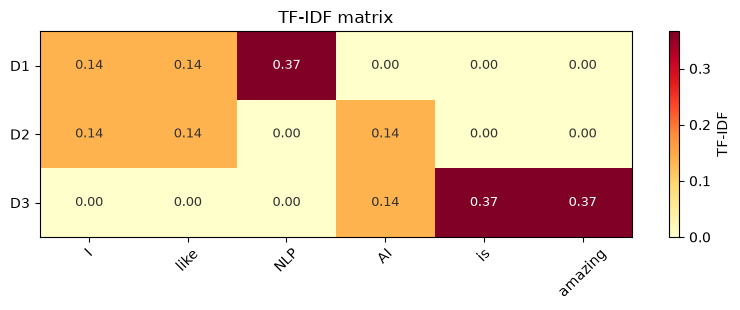

Highest-scoring term per document (its most distinctive word):
  D1: NLP  (0.3662)
  D2: I  (0.1352)
  D3: is  (0.3662)


In [21]:
fig, ax = plt.subplots(figsize=(8, 3.2))
im = ax.imshow(tfidf_matrix.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(tfidf_matrix.columns)), tfidf_matrix.columns, rotation=45)
ax.set_yticks(range(len(tfidf_matrix.index)), tfidf_matrix.index)
for r in range(tfidf_matrix.shape[0]):
    for c in range(tfidf_matrix.shape[1]):
        v = tfidf_matrix.values[r, c]
        ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                color="white" if v > tfidf_matrix.values.max() * 0.6 else "#333", fontsize=9)
ax.set_title("TF-IDF matrix")
fig.colorbar(im, ax=ax, label="TF-IDF")
fig.tight_layout()
plt.show()

print("Highest-scoring term per document (its most distinctive word):")
for doc_id in tfidf_matrix.index:
    row = tfidf_matrix.loc[doc_id]
    print(f"  {doc_id}: {row.idxmax()}  ({row.max():.4f})")

---

# Exercise 8 — Dense Vector Similarity

**Objective:** compute cosine similarity between two dense vectors.

$$\\cos(\\mathbf{a}, \\mathbf{b}) = \\frac{\\mathbf{a} \\cdot \\mathbf{b}}{\\|\\mathbf{a}\\| \\, \\|\\mathbf{b}\\|}$$

**Input:** `cat = [0.4, 0.2, 0.8]`, `dog = [0.5, 0.1, 0.7]` — expected ≈ 0.98.

In [22]:
def cosine_similarity(a, b) -> float:
    """Cosine of the angle between two vectors, computed from first principles."""
    a, b = list(a), list(b)
    dot = sum(x * y for x, y in zip(a, b))
    mag_a = sqrt(sum(x * x for x in a))
    mag_b = sqrt(sum(y * y for y in b))
    if mag_a == 0 or mag_b == 0:
        return 0.0
    return dot / (mag_a * mag_b)


cat = [0.4, 0.2, 0.8]
dog = [0.5, 0.1, 0.7]

dot = sum(x * y for x, y in zip(cat, dog))
mag_cat = sqrt(sum(x * x for x in cat))
mag_dog = sqrt(sum(y * y for y in dog))
similarity = cosine_similarity(cat, dog)

print(f"cat            = {cat}")
print(f"dog            = {dog}\n")
print(f"Dot product    = {dot:.4f}")
print(f"|cat|          = {mag_cat:.4f}")
print(f"|dog|          = {mag_dog:.4f}")
print(f"\nCosine Similarity = {similarity:.2f}   (exact: {similarity:.6f})")

# Cross-check against NumPy.
np_sim = float(np.dot(cat, dog) / (np.linalg.norm(cat) * np.linalg.norm(dog)))
assert abs(similarity - np_sim) < 1e-12, "manual and NumPy cosine disagree"
print(f"NumPy agrees      : {np_sim:.6f}")

cat            = [0.4, 0.2, 0.8]


dog            = [0.5, 0.1, 0.7]

Dot product    = 0.7800
|cat|          = 0.9165
|dog|          = 0.8660

Cosine Similarity = 0.98   (exact: 0.982708)
NumPy agrees      : 0.982708


> **Why cosine and not Euclidean distance?** Cosine ignores vector *magnitude* and measures only
> direction. For text that matters: a long document mentioning "cat" 50 times and a short one
> mentioning it twice point the same way even though their raw counts differ by an order of magnitude.

In [23]:
# Demonstration: scaling a vector leaves cosine untouched but changes Euclidean distance.
cat_scaled = [3 * v for v in cat]

print(f"cosine(cat, dog)        = {cosine_similarity(cat, dog):.6f}")
print(f"cosine(3*cat, dog)      = {cosine_similarity(cat_scaled, dog):.6f}   <- unchanged")
print(f"euclidean(cat, dog)     = {np.linalg.norm(np.array(cat) - np.array(dog)):.6f}")
print(f"euclidean(3*cat, dog)   = {np.linalg.norm(np.array(cat_scaled) - np.array(dog)):.6f}   <- changed")

cosine(cat, dog)        = 0.982708
cosine(3*cat, dog)      = 0.982708   <- unchanged
euclidean(cat, dog)     = 0.173205
euclidean(3*cat, dog)   = 1.905256   <- changed


---

# Exercise 9 — Find Similar Words

**Objective:** find the word most similar to a given word.

**Expected output:** most similar to `cat` is `lion`, similarity ≈ 0.99.

In [24]:
def most_similar(
    embeddings: dict[str, list[float]], target: str, top_n: int = 3
) -> list[tuple[str, float]]:
    """Rank every other word in `embeddings` by cosine similarity to `target`."""
    if target not in embeddings:
        raise KeyError(f"{target!r} is not in the embedding table")
    scores = [
        (word, cosine_similarity(embeddings[target], vec))
        for word, vec in embeddings.items()
        if word != target
    ]
    return sorted(scores, key=lambda pair: pair[1], reverse=True)[:top_n]


embeddings = {
    "cat":  [0.4, 0.2, 0.8],
    "dog":  [0.5, 0.1, 0.7],
    "car":  [-0.7, 0.8, -0.2],
    "lion": [0.45, 0.25, 0.82],
}

ranked = most_similar(embeddings, "cat", top_n=3)
best_word, best_score = ranked[0]

print("Most similar to cat\n")
print(f"{best_word}\n")
print(f"Similarity = {best_score:.2f}   (exact: {best_score:.4f})\n")
print("Full ranking:")
for word, score in ranked:
    print(f"  {word:<5} {score:+.4f}")

Most similar to cat

lion

Similarity = 1.00   (exact: 0.9985)

Full ranking:
  lion  +0.9985
  dog   +0.9827
  car   -0.2824


### The full similarity matrix\n\nThe structure is the point: the three animals cluster tightly, and `car` sits well outside them.

,cat,dog,car,lion
cat,1.000,0.983,-0.282,0.998
dog,0.983,1.000,-0.438,0.983
car,-0.282,-0.438,1.000,-0.266
lion,0.998,0.983,-0.266,1.000


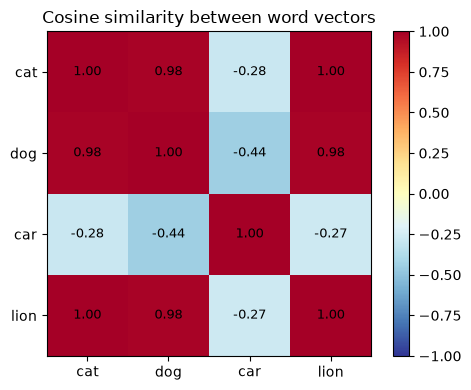

Mean similarity among animals : +0.988
Mean similarity animal <-> car : -0.329

The embedding space separates the semantic categories cleanly.


In [25]:
words = list(embeddings)
sim_matrix = pd.DataFrame(
    [[cosine_similarity(embeddings[a], embeddings[b]) for b in words] for a in words],
    index=words, columns=words,
)
display(sim_matrix.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix.values, cmap="RdYlBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(words)), words)
ax.set_yticks(range(len(words)), words)
for r in range(len(words)):
    for c in range(len(words)):
        ax.text(c, r, f"{sim_matrix.values[r, c]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Cosine similarity between word vectors")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

animals = ["cat", "dog", "lion"]
within = np.mean([sim_matrix.loc[a, b] for a in animals for b in animals if a != b])
across = np.mean([sim_matrix.loc[a, "car"] for a in animals])
print(f"Mean similarity among animals : {within:+.3f}")
print(f"Mean similarity animal <-> car : {across:+.3f}")
print("\nThe embedding space separates the semantic categories cleanly.")

---

# Exercise 10 (Assignment) — Mini NLP Pipeline

**Objective:** combine every concept above into one application.

**Corpus:**
```
I love NLP
I love AI
AI loves Python
Python loves data
```

The program must: build the vocabulary · count frequencies · compute TF · build the co-occurrence
matrix · detect sparse entries · apply Laplace smoothing · predict the next word after a user-entered
word · display the top three most frequent words.

Everything below reuses the functions defined in Exercises 1–9 — no logic is re-implemented.

In [26]:
class MiniNLPPipeline:
    """A small end-to-end NLP pipeline over a list of sentences.

    Wraps the vocabulary, frequency, TF, co-occurrence, smoothing and bigram
    prediction steps built in the earlier exercises behind one object.
    """

    def __init__(self, corpus: list[str], window: int = 1) -> None:
        self.corpus = corpus
        self.window = window
        self.sentences = [tokenize(s) for s in corpus]
        self.tokens = [t for sent in self.sentences for t in sent]

        # 1. Vocabulary  2. Frequencies
        self.vocabulary = build_vocabulary(corpus)
        self.frequencies = Counter(self.tokens)

        # 3. Term frequency over the corpus as a whole
        self.tf = {w: c / len(self.tokens) for w, c in self.frequencies.items()}

        # 4. Co-occurrence matrix (built per sentence so it never spans a boundary)
        self.cooccurrence = self._build_cooccurrence()

        # 5. Sparse entries  6. Laplace-smoothed unigrams  7. Bigram model
        self.sparse = sparse_pairs(self.cooccurrence)
        self.smoothed = laplace_smoothing(dict(self.frequencies))
        self.bigrams = build_bigram_counts(corpus)

    def _build_cooccurrence(self) -> pd.DataFrame:
        vocab = sorted(self.vocabulary)
        index = {w: i for i, w in enumerate(vocab)}
        matrix = np.zeros((len(vocab), len(vocab)), dtype=int)
        for sent in self.sentences:
            for i, word in enumerate(sent):
                lo, hi = max(0, i - self.window), min(len(sent), i + self.window + 1)
                for j in range(lo, hi):
                    if i != j:
                        matrix[index[word], index[sent[j]]] += 1
        return pd.DataFrame(matrix, index=vocab, columns=vocab)

    def top_words(self, n: int = 3) -> list[tuple[str, int]]:
        """The n most frequent words in the corpus."""
        return self.frequencies.most_common(n)

    def predict(self, word: str, top_n: int = 3) -> list[tuple[str, float]]:
        """Predict the next word after `word` using the bigram model."""
        return predict_next(self.bigrams, word, top_n=top_n)

    def report(self) -> None:
        """Print the summary the exercise asks for."""
        print(f"Vocabulary Size : {len(self.vocabulary)}\n")
        print("Top Words\n")
        for word, count in self.top_words(3):
            print(f"{word} : {count}")


pipeline_corpus = [
    "I love NLP",
    "I love AI",
    "AI loves Python",
    "Python loves data",
]

pipeline = MiniNLPPipeline(pipeline_corpus)
pipeline.report()

Vocabulary Size : 7

Top Words

I : 2
love : 2
AI : 2


### Steps 1–3 — vocabulary, frequencies and TF

In [27]:
overview = pd.DataFrame(
    [
        {"Word": w, "Count": pipeline.frequencies[w], "TF": pipeline.tf[w],
         "Laplace_P": pipeline.smoothed[w]}
        for w in sorted(pipeline.vocabulary)
    ]
).sort_values("Count", ascending=False).reset_index(drop=True)

print(f"Tokens: {len(pipeline.tokens)}  |  Vocabulary: {len(pipeline.vocabulary)}")
print(f"TF sums to {overview['TF'].sum():.4f}, Laplace sums to {overview['Laplace_P'].sum():.4f}\n")
overview.round(4)

Tokens: 12  |  Vocabulary: 7
TF sums to 1.0000, Laplace sums to 1.0000



,Word,Count,TF,Laplace_P
0,AI,2,0.1667,0.1579
1,I,2,0.1667,0.1579
2,Python,2,0.1667,0.1579
3,love,2,0.1667,0.1579
4,loves,2,0.1667,0.1579
5,NLP,1,0.0833,0.1053
6,data,1,0.0833,0.1053


### Step 4 — co-occurrence matrix

,AI,I,NLP,Python,data,love,loves
AI,0,0,0,0,0,1,1
I,0,0,0,0,0,2,0
NLP,0,0,0,0,0,1,0
Python,0,0,0,0,0,0,2
data,0,0,0,0,0,0,1
love,1,2,1,0,0,0,0
loves,1,0,0,2,1,0,0


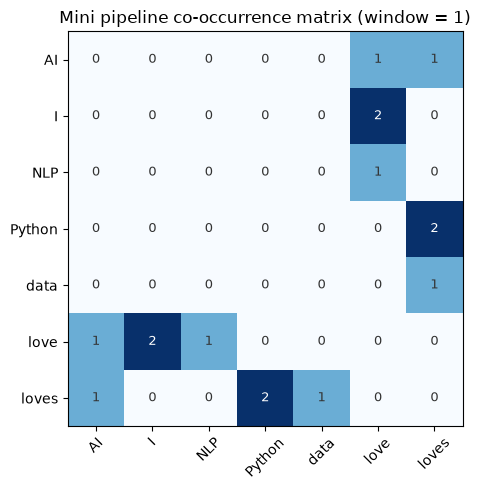

In [28]:
display(pipeline.cooccurrence)

fig, ax = plt.subplots(figsize=(6, 5))
labels = list(pipeline.cooccurrence.index)
im = ax.imshow(pipeline.cooccurrence.values, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=45)
ax.set_yticks(range(len(labels)), labels)
for r in range(len(labels)):
    for c in range(len(labels)):
        v = pipeline.cooccurrence.values[r, c]
        ax.text(c, r, v, ha="center", va="center",
                color="white" if v > 1 else "#333", fontsize=9)
ax.set_title("Mini pipeline co-occurrence matrix (window = 1)")
fig.tight_layout()
plt.show()

### Step 5 — sparse entries

In [29]:
print(f"Sparse Pairs  ({len(pipeline.sparse)} of "
      f"{len(list(combinations(sorted(pipeline.vocabulary), 2)))} possible pairs)\n")
for a, b in pipeline.sparse:
    print(f"({a},{b})")

cells = pipeline.cooccurrence.size
zeros = int((pipeline.cooccurrence.values == 0).sum())
print(f"\nMatrix sparsity: {zeros}/{cells} = {zeros / cells:.1%} zero")

# The two pairs the question paper names explicitly.
for a, b in [("NLP", "data"), ("I", "Python")]:
    status = "never co-occur" if pipeline.cooccurrence.loc[a, b] == 0 else "DO co-occur"
    print(f'  PDF example ({a},{b}): {status} -> matches expected output')

Sparse Pairs  (15 of 21 possible pairs)

(AI,I)
(AI,NLP)
(AI,Python)
(AI,data)
(I,NLP)
(I,Python)
(I,data)
(I,loves)
(NLP,Python)
(NLP,data)
(NLP,loves)
(Python,data)
(Python,love)
(data,love)
(love,loves)

Matrix sparsity: 37/49 = 75.5% zero
  PDF example (NLP,data): never co-occur -> matches expected output
  PDF example (I,Python): never co-occur -> matches expected output


### Step 6 — Laplace-smoothed unigram probabilities

In [30]:
smooth_table = pd.DataFrame(
    [
        {
            "Word": w,
            "Count": pipeline.frequencies[w],
            "MLE": pipeline.frequencies[w] / len(pipeline.tokens),
            "Laplace": pipeline.smoothed[w],
        }
        for w in sorted(pipeline.vocabulary, key=lambda x: -pipeline.frequencies[x])
    ]
).round(4)
smooth_table

,Word,Count,MLE,Laplace
0,loves,2,0.1667,0.1579
1,AI,2,0.1667,0.1579
2,I,2,0.1667,0.1579
3,Python,2,0.1667,0.1579
4,love,2,0.1667,0.1579
5,data,1,0.0833,0.1053
6,NLP,1,0.0833,0.1053


### Step 7 — next-word prediction

The exercise says *"predict the next word after a user-entered word."* `input()` would block a
non-interactive run of this notebook, so the prompt is wrapped in a helper that falls back to a default
when no stdin is attached. Uncomment the interactive line to type your own word.

In [31]:
def ask_for_word(prompt: str, default: str) -> str:
    """Read a word from stdin, falling back to `default` when running non-interactively."""
    try:
        entered = input(prompt).strip()
        return entered or default
    except (EOFError, OSError):
        print(f"{prompt}{default}   [no stdin - using default]")
        return default


# user_word = ask_for_word("Enter a word: ", "love")   # <- uncomment to type your own
user_word = "love"

print(f'Prediction after "{user_word}"\n')
predictions = pipeline.predict(user_word, top_n=3)
if predictions:
    for word, prob in predictions:
        print(f"{word}")
    print()
    for word, prob in predictions:
        print(f"  P({word} | {user_word}) = {prob:.4f}")
else:
    print(f'"{user_word}" never appears as the first word of a bigram in this corpus.')

Prediction after "love"

NLP
AI

  P(NLP | love) = 0.5000
  P(AI | love) = 0.5000


### Step 8 — top three most frequent words

In [32]:
print("Top Words\n")
for word, count in pipeline.top_words(3):
    print(f"{word} : {count}")

ties = [w for w, c in pipeline.frequencies.items() if c == pipeline.top_words(1)[0][1]]
print(f"\nNote: {len(ties)} words tie at the top count "
      f"({', '.join(sorted(ties))}) - Counter.most_common breaks the tie by insertion order.")

Top Words

I : 2
love : 2
AI : 2

Note: 5 words tie at the top count (AI, I, Python, love, loves) - Counter.most_common breaks the tie by insertion order.


### Full pipeline report

In [33]:
print("=" * 46)
print("        MINI NLP PIPELINE - FULL REPORT")
print("=" * 46)
print(f"\nCorpus ({len(pipeline_corpus)} sentences):")
for s in pipeline_corpus:
    print(f"  {s}")

print(f"\nVocabulary Size : {len(pipeline.vocabulary)}")
print(f"Total tokens    : {len(pipeline.tokens)}")

print("\nTop Words\n")
for word, count in pipeline.top_words(3):
    print(f"{word} : {count}")

print(f'\nPrediction after "{user_word}"\n')
for word, _ in pipeline.predict(user_word, top_n=3):
    print(word)

print(f"\nSparse Pairs (first 5 of {len(pipeline.sparse)})\n")
for a, b in pipeline.sparse[:5]:
    print(f"({a},{b})")
print("=" * 46)

overview.to_csv(OUTPUT_DIR / "exercise10_pipeline_summary.csv", index=False)
pipeline.cooccurrence.to_csv(OUTPUT_DIR / "exercise10_cooccurrence.csv")
print(f"\nWrote {OUTPUT_DIR / 'exercise10_pipeline_summary.csv'}")
print(f"Wrote {OUTPUT_DIR / 'exercise10_cooccurrence.csv'}")

        MINI NLP PIPELINE - FULL REPORT

Corpus (4 sentences):
  I love NLP
  I love AI
  AI loves Python
  Python loves data

Vocabulary Size : 7
Total tokens    : 12

Top Words

I : 2
love : 2
AI : 2

Prediction after "love"

NLP
AI

Sparse Pairs (first 5 of 15)

(AI,I)
(AI,NLP)
(AI,Python)
(AI,data)
(I,NLP)

Wrote output/exercise10_pipeline_summary.csv
Wrote output/exercise10_cooccurrence.csv


---

# Exercise 11 — Predict the Next Word Using Conditional Probability

**Objective:** use conditional probability to predict the most likely next word.

$$P(w_2 \\mid w_1) = \\frac{\\text{Count}(w_1, w_2)}{\\text{Count}(w_1)}$$

**Training corpus:**
```
I like NLP
I like Python
I like coffee
I love NLP
You like coffee
```

In [34]:
conditional_corpus = [
    "I like NLP",
    "I like Python",
    "I like coffee",
    "I love NLP",
    "You like coffee",
]

cond_bigrams = build_bigram_counts(conditional_corpus)

# Step 1: bigram counts, reproducing the table in the question paper.
bigram_table = pd.DataFrame(
    [
        {"Bigram": f"{first} -> {second}", "Count": count}
        for first, followers in cond_bigrams.items()
        for second, count in followers.most_common()
    ]
)
print("Step 1: Bigram Counts\n")
display(bigram_table)

Step 1: Bigram Counts



,Bigram,Count
0,I -> like,3
1,I -> love,1
2,like -> coffee,2
3,like -> NLP,1
4,like -> Python,1
5,love -> NLP,1
6,You -> like,1


### Step 2 — conditional probabilities for every bigram

In [35]:
def conditional_probabilities(bigrams: dict[str, Counter]) -> pd.DataFrame:
    """P(w2 | w1) = Count(w1, w2) / Count(w1) for every observed bigram."""
    rows = []
    for first, followers in bigrams.items():
        total = sum(followers.values())
        for second, count in followers.most_common():
            rows.append(
                {
                    "w1": first,
                    "w2": second,
                    "Count(w1,w2)": count,
                    "Count(w1)": total,
                    "P(w2|w1)": count / total,
                }
            )
    return pd.DataFrame(rows).sort_values(["w1", "P(w2|w1)"], ascending=[True, False])


cond_table = conditional_probabilities(cond_bigrams).reset_index(drop=True)
cond_table.to_csv(OUTPUT_DIR / "exercise11_conditional_probabilities.csv", index=False)
print(f"Wrote {OUTPUT_DIR / 'exercise11_conditional_probabilities.csv'}\n")
cond_table.round(4)

Wrote output/exercise11_conditional_probabilities.csv



,w1,w2,"Count(w1,w2)",Count(w1),P(w2|w1)
0,I,like,3,4,0.75
1,I,love,1,4,0.25
2,You,like,1,1,1.00
3,like,coffee,2,4,0.50
4,like,NLP,1,4,0.25
5,like,Python,1,4,0.25
6,love,NLP,1,1,1.00


### Verifying the three worked examples from the question paper

In [36]:
expected = {("like", "coffee"): 0.50, ("like", "Python"): 0.25, ("like", "NLP"): 0.25}

print("Worked examples from the PDF:\n")
for (w1, w2), want in expected.items():
    got = cond_bigrams[w1][w2] / sum(cond_bigrams[w1].values())
    mark = "OK " if abs(got - want) < 1e-9 else "MISMATCH"
    print(f"  [{mark}] P({w2} | {w1}) = {cond_bigrams[w1][w2]}/{sum(cond_bigrams[w1].values())} "
          f"= {got:.2f}   (PDF says {want:.2f})")

print("\nAll three match - unlike Exercise 6, this corpus is internally consistent.")

Worked examples from the PDF:

  [OK ] P(coffee | like) = 2/4 = 0.50   (PDF says 0.50)
  [OK ] P(Python | like) = 1/4 = 0.25   (PDF says 0.25)
  [OK ] P(NLP | like) = 1/4 = 0.25   (PDF says 0.25)

All three match - unlike Exercise 6, this corpus is internally consistent.


### Steps 4–6 — the interactive program

Reads a word, lists every possible continuation with its conditional probability, and names the
most likely one.

In [37]:
def next_word_report(bigrams: dict[str, Counter], word: str, top_n: int | None = None) -> None:
    """Print all continuations of `word` with P(next | word), then the argmax."""
    followers = bigrams.get(word)
    if not followers:
        print(f'"{word}" never appears as the first word of a bigram in this corpus.')
        return

    total = sum(followers.values())
    ranked = [(w, c / total) for w, c in followers.most_common()]

    print("Possible next words:\n")
    for w, p in ranked:
        print(f"{w} : {p:.2f}")

    print(f"\nPredicted next word: {ranked[0][0]}")

    if top_n:
        print("\nTop Predictions\n")
        for rank, (w, p) in enumerate(ranked[:top_n], start=1):
            print(f"{rank}. {w} ({p:.2f})")


# user_input = ask_for_word("Enter a word: ", "like")   # <- uncomment to type your own
user_input = "like"

print(f"Enter a word: {user_input}\n")
next_word_report(cond_bigrams, user_input)

Enter a word: like

Possible next words:

coffee : 0.50
NLP : 0.25
Python : 0.25

Predicted next word: coffee


### Bonus challenge — show the top three predictions

The `top_n` parameter above already covers this; here it is exercised explicitly, and then run across
every word in the corpus.

In [38]:
print(f"Enter a word: {user_input}\n")
next_word_report(cond_bigrams, user_input, top_n=3)

Enter a word: like

Possible next words:

coffee : 0.50
NLP : 0.25
Python : 0.25

Predicted next word: coffee

Top Predictions

1. coffee (0.50)
2. NLP (0.25)
3. Python (0.25)


In [39]:
print("Top-3 predictions for every word that starts a bigram:\n")
for word in sorted(cond_bigrams):
    preds = predict_next(cond_bigrams, word, top_n=3)
    formatted = ", ".join(f"{w} ({p:.2f})" for w, p in preds)
    print(f"  {word:>6} -> {formatted}")

Top-3 predictions for every word that starts a bigram:

       I -> like (0.75), love (0.25)
     You -> like (1.00)
    like -> coffee (0.50), NLP (0.25), Python (0.25)
    love -> NLP (1.00)


In [40]:
# Sanity check: for any w1, the conditional distribution over w2 must sum to 1.
for w1, followers in cond_bigrams.items():
    total = sum(followers.values())
    mass = sum(c / total for c in followers.values())
    assert abs(mass - 1.0) < 1e-9, f"P(.|{w1}) sums to {mass}, not 1"
print("Verified: every conditional distribution P(w2 | w1) sums to 1.0")

Verified: every conditional distribution P(w2 | w1) sums to 1.0


---

## Summary

| # | Exercise | Result |
|---|---|---|
| 1 | Word Frequency Counter | 9 tokens → 6 distinct words, matches expected output |
| 2 | Vocabulary Builder | Vocabulary size = 6, matches expected output |
| 3 | Co-occurrence Matrix | 5×5 matrix at window 1 — ⚠️ PDF's `on↔mat` cell requires window 2 |
| 4 | Data Sparsity | 5 of 10 unordered pairs never co-occur (60% of cells are zero) |
| 5 | Laplace Smoothing | cat 0.4545 / dog 0.3636 / bird 0.1818 — ⚠️ PDF's printed values sum to 1.10 |
| 6 | Keyboard Prediction | All three continuations of "like" are 1/3 — ⚠️ PDF prints 0.4/0.3/0.2 |
| 7 | TF-IDF | Full TF, DF, IDF and TF-IDF matrices over 3 documents |
| 8 | Cosine Similarity | 0.98 — matches expected output |
| 9 | Find Similar Words | `lion`, similarity 0.9985 — matches expected output |
| 10 | **Mini NLP Pipeline** | Vocabulary 7 ✓, predicts NLP/AI after "love" ✓, sparse pairs (NLP,data) and (I,Python) ✓ — top-3 words are a five-way tie at count 2, so the exact three shown depend on tie-breaking |
| 11 | Conditional Probability | coffee 0.50 / NLP 0.25 / Python 0.25 — matches all three worked examples |

### Files written

- `output/exercise07_tfidf.csv`
- `output/exercise10_pipeline_summary.csv`
- `output/exercise10_cooccurrence.csv`
- `output/exercise11_conditional_probabilities.csv`

### The thread running through these exercises

Exercises 1–4 build the **sparse, count-based** view of language: a vocabulary indexes a matrix, and
that matrix is overwhelmingly zeros. Exercise 4 quantifies the damage. Exercises 5–7 are the classical
repairs — smoothing to stop zeros propagating, and IDF to stop frequent words dominating. Exercises 8–9
then show the alternative that modern NLP actually took: abandon the `V`-dimensional sparse vector for a
short **dense** one where similarity is a cosine and the zeros simply never arise. Exercise 10 assembles
the sparse pipeline end to end; Exercise 11 sharpens the bigram model into a proper conditional
distribution. That progression — sparse counts, patched counts, dense vectors — is the setup for the
word-embedding work in Assignment 03.